In this notebook we will implement a neural network that can learn the parameters of a linear optimization problem. 

# Part 1: data obtaining and preprocessing

In [1]:
import numpy as np
import deep_inv_opt as io
import deep_inv_opt.plot as iop
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from diffcp import SolverError
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import contextlib
import io as io2


import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.max_open_warning'] = 0  # Let the plots flow!
%matplotlib inline

In [2]:
u_train = io.tensor(np.linspace(0, 6, 1024).reshape((-1, 1)))
u_train

tensor([[0.0000e+00],
        [5.8651e-03],
        [1.1730e-02],
        ...,
        [5.9883e+00],
        [5.9941e+00],
        [6.0000e+00]], dtype=torch.float64)

In [3]:
u_train, u_val = train_test_split(u_train, test_size=0.2, random_state=42)

u_train, u_test = train_test_split(u_train, test_size=0.15, random_state=42)

In [4]:
u_train

tensor([[3.3255e+00],
        [4.7918e+00],
        [5.9062e+00],
        [4.1349e+00],
        [2.4751e+00],
        [5.7537e+00],
        [2.7449e+00],
        [4.9619e+00],
        [4.9736e+00],
        [5.3724e+00],
        [3.1026e+00],
        [4.9150e+00],
        [1.8827e+00],
        [4.3460e+00],
        [2.4399e+00],
        [4.7449e+00],
        [5.9003e+00],
        [1.1906e+00],
        [4.7155e+00],
        [3.7126e+00],
        [3.3431e-01],
        [3.3021e+00],
        [1.8768e-01],
        [5.6188e+00],
        [2.9677e+00],
        [1.4721e+00],
        [2.2346e+00],
        [3.6129e+00],
        [3.1144e+00],
        [5.3548e+00],
        [4.6862e+00],
        [2.2757e+00],
        [1.6070e+00],
        [4.5572e+00],
        [1.6657e+00],
        [3.5894e+00],
        [2.5572e+00],
        [4.4047e+00],
        [4.8739e+00],
        [4.4399e+00],
        [1.1789e+00],
        [4.0997e+00],
        [2.7155e+00],
        [4.2522e+00],
        [5.0499e+00],
        [5

In [5]:
u_val

tensor([[3.0792],
        [2.0938],
        [2.6041],
        [0.1818],
        [3.6246],
        [3.4428],
        [2.6217],
        [4.3050],
        [0.4457],
        [4.1935],
        [2.1701],
        [0.4106],
        [3.9707],
        [0.5924],
        [3.6422],
        [3.8299],
        [1.6422],
        [2.4927],
        [2.3695],
        [4.3930],
        [0.5630],
        [5.2903],
        [1.5308],
        [1.8299],
        [3.1085],
        [4.0821],
        [2.1232],
        [1.6950],
        [5.1965],
        [5.8592],
        [3.5836],
        [4.0762],
        [5.9179],
        [1.9179],
        [2.4106],
        [1.6774],
        [1.2493],
        [3.6950],
        [2.5337],
        [1.1672],
        [3.7419],
        [5.6540],
        [4.8680],
        [3.4663],
        [2.7977],
        [2.3109],
        [5.4897],
        [1.4311],
        [3.5953],
        [1.7009],
        [5.2551],
        [3.7713],
        [0.3460],
        [4.0293],
        [1.8710],
        [0

In [6]:
u_test

tensor([[5.4721],
        [5.4428],
        [0.7625],
        [5.7947],
        [2.2933],
        [0.8387],
        [1.3138],
        [3.2962],
        [1.0147],
        [1.7185],
        [3.0909],
        [0.4399],
        [2.4516],
        [4.9384],
        [2.0997],
        [3.8182],
        [0.2698],
        [2.4340],
        [1.0909],
        [4.3519],
        [2.4868],
        [0.9208],
        [3.4311],
        [2.0293],
        [1.0850],
        [3.7361],
        [3.3842],
        [2.4809],
        [1.7713],
        [4.2933],
        [3.0029],
        [4.5044],
        [4.1232],
        [3.1261],
        [5.5249],
        [4.6100],
        [1.9648],
        [1.0440],
        [0.9326],
        [0.1114],
        [2.7038],
        [3.8886],
        [0.2405],
        [0.3754],
        [5.9296],
        [1.5601],
        [3.4076],
        [3.4194],
        [1.6364],
        [3.5484],
        [4.5748],
        [5.2082],
        [2.9795],
        [4.6217],
        [1.3607],
        [2

Now we generate the data from the real problem.

In [7]:
# class ExamplePLP(io.ParametricLP):
#     # Generate an LP from a given feature vector u and weight vector w.
#     def generate(self, u, w):
#         c = [[torch.cos(w + u**2 / 2)],
#              [torch.sin(w + u**2 / 2)]]

#         A_ub = [[ 0.0,  1.0],
#                 [ 0.0, -1.0],
#                 [ 1.0,  0.0],
#                 [-1.0,  0.0],
#                 [ 1.0,  1.0],
#                 [-1.0, -1.0],
#                 [-1.0,  1.0],
#                 [ 1.0, -1.0]
#                 ]

#         b_ub = [[ 30.0 ],
#                 [ 30.0 ],
#                 [ 30.0 ],
#                 [ 30.0 ],
#                 [ 40.0 ],
#                 [ 40.0 ],
#                 [ 40.0 ],
#                 [ 40.0 ]
#                 ]
        
#         return c, A_ub, b_ub, None, None

In [8]:
class ExamplePLP(io.ParametricLP):
    # Generate an LP from a given feature vector u and weight vector w.
    def generate(self, u, w):
        c = [[torch.cos(w + u**2 / 2)],
             [torch.sin(w + u**2 / 2)]]

        A_ub = [[ 0.0,  1.0],
                [ 0.0, -1.0],
                [ 1.0,  0.0],
                [-1.0,  0.0],
                [ 1.0,  1.0],
                [-1.0, -1.0],
                [-1.0,  1.0],
                [ 1.0, -1.0]
                ]

        b_ub = [[ 60.0 ],
                [  0.0 ],
                [ 60.0 ],
                [  0.0 ],
                [ 100.0 ],
                [-20.0 ],
                [ 40.0 ],
                [ 40.0 ]
                ]
        
        return c, A_ub, b_ub, None, None

In [9]:
plp_true = ExamplePLP(weights=[0.8])

In [10]:
# Generate training targets by solve the true PLP.
x_train = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_train])
# torch.save(x_train, "x_train.pt")

x_val = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_val])
# torch.save(x_val, "x_val.pt")

x_test = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_test])
# torch.save(x_test, "x_test.pt")

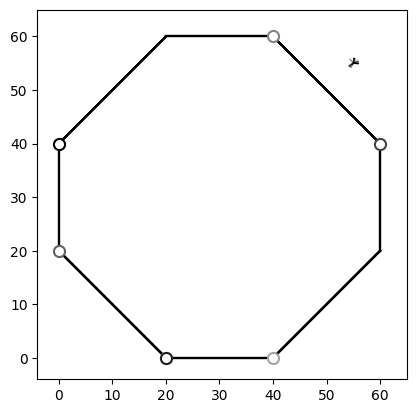

In [11]:
u_show = io.tensor(np.linspace(0, 6, 8).reshape((-1, 1)))

xylim = ((-4, 65), (-4, 65))
cxy = (55, 55)

iop.plot_parametric_linprog(plp_true, u_show, xylim=xylim, cxy=cxy, show_solutions=True)

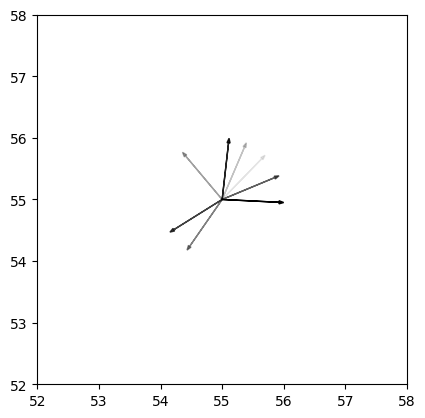

In [12]:
u_show = io.tensor(np.linspace(0, 6, 8).reshape((-1, 1)))

xylim = ((52, 58), (52, 58))
cxy = (55, 55)

iop.plot_parametric_linprog(plp_true, u_show, xylim=xylim, cxy=cxy, show_solutions=True)

In [13]:
# x_val = torch.load("x_val.pt")
x_val

tensor([[3.3032e-04, 4.0000e+01],
        [6.0000e+01, 2.0000e+01],
        [4.0000e+01, 6.0000e+01],
        [2.0000e+01, 3.4334e-04],
        [2.0000e+01, 4.7857e-05],
        [4.8244e-05, 2.0000e+01],
        [4.0000e+01, 6.0000e+01],
        [6.0000e+01, 4.0000e+01],
        [2.0000e+01, 8.5629e-05],
        [6.0000e+01, 4.0000e+01],
        [6.0000e+01, 3.9998e+01],
        [2.0000e+01, 9.8624e-05],
        [6.0000e+01, 2.0000e+01],
        [2.0000e+01, 7.4961e-05],
        [2.0000e+01, 3.9742e-05],
        [4.0000e+01, 4.4577e-05],
        [4.0000e+01, 1.0462e-04],
        [5.9999e+01, 4.0001e+01],
        [6.0000e+01, 4.0000e+01],
        [4.0000e+01, 6.0000e+01],
        [2.0000e+01, 8.2212e-05],
        [4.0000e+01, 1.1024e-04],
        [4.0000e+01, 4.3143e-05],
        [6.0000e+01, 2.0000e+01],
        [1.0630e-04, 4.0000e+01],
        [6.0000e+01, 2.0000e+01],
        [6.0000e+01, 2.0000e+01],
        [4.0000e+01, 1.1863e-04],
        [4.0000e+01, 2.7820e-05],
        [2.000

In [14]:
# x_train = torch.load("x_train.pt")
x_train

tensor([[1.4454e-05, 2.0000e+01],
        [4.5036e-05, 4.0000e+01],
        [5.5234e-05, 4.0000e+01],
        ...,
        [6.0000e+01, 2.0000e+01],
        [2.0000e+01, 1.9679e-05],
        [1.9998e+01, 1.7550e-03]], dtype=torch.float64)

In [15]:
# x_test = torch.load("x_test.pt")
x_test

tensor([[6.0000e+01, 4.0000e+01],
        [6.0000e+01, 2.0000e+01],
        [2.0000e+01, 4.7116e-05],
        [2.0000e+01, 6.0000e+01],
        [6.0000e+01, 4.0000e+01],
        [2.0000e+01, 3.9536e-05],
        [4.0000e+01, 2.2162e-05],
        [1.4525e-05, 4.0000e+01],
        [2.0000e+01, 1.9280e-05],
        [4.0000e+01, 1.7806e-04],
        [1.7928e-04, 4.0000e+01],
        [2.0000e+01, 8.7618e-05],
        [6.0000e+01, 4.0000e+01],
        [4.0437e-05, 2.0000e+01],
        [6.0000e+01, 2.0000e+01],
        [4.0000e+01, 4.1273e-05],
        [2.0000e+01, 2.0965e-04],
        [6.0000e+01, 4.0000e+01],
        [2.0000e+01, 2.4732e-05],
        [4.0000e+01, 6.0000e+01],
        [6.0000e+01, 4.0000e+01],
        [2.0000e+01, 2.5167e-05],
        [3.7949e-05, 2.0000e+01],
        [6.0000e+01, 2.0000e+01],
        [2.0000e+01, 2.4961e-05],
        [2.0000e+01, 1.6385e-05],
        [1.8864e-05, 2.0000e+01],
        [6.0000e+01, 4.0000e+01],
        [5.9999e+01, 1.9999e+01],
        [6.000

# Part 2: model definition and training

In [16]:
# Check if we are using a GPU or CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [17]:
learning_rate = 1e-3
batch_size = 16

In [18]:
# Dataset and DataLoader definition
class UDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data.clone().to(dtype=torch.float32) 
        self.targets = targets.clone().to(dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

# Dataset (u, x)
dataset = UDataset(u_train, x_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [19]:
val_dataset = UDataset(u_val, x_val)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = UDataset(u_test, x_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [20]:
def gradient_descent_solver(c, A, b, lr=0.01, max_iter=1000, tol=1e-6, M=1000.0):
    """
    Solve a linear optimization problem with constraints using gradient descent.

    Parameters:
    - c: Cost vector (n,)
    - A: Constraint matrix (m, n)
    - b: Constraint vector (m,)
    - lr: Learning rate
    - max_iter: Maximum number of iterations
    - tol: Convergence tolerance

    Returns:
    - x: Optimal solution found
    """
    n = c.shape[0]
    x = torch.zeros(n, dtype=c.dtype, requires_grad=True)
    optimizer = torch.optim.SGD([x], lr=lr)

    for _ in range(max_iter):
        optimizer.zero_grad()
        objective = torch.dot(c, x) + M * torch.sum(torch.relu(A @ x - b)) # relu(x) = max(0, x)
        objective.backward(retain_graph=True)
        optimizer.step()

        if torch.norm(x.grad) < tol:
            break
    return x

def newton_solver(c, A, b, max_iter=100, tol=1e-6, M=1000.0):
    """
    Solve a linear optimization problem with constraints using the Newton method.

    Parameters:
    - c: Cost vector (n,)
    - A: Constraint matrix (m, n)
    - b: Constraint vector (m,)
    - max_iter: Maximum number of iterations
    - tol: Convergence tolerance

    Returns:
    - x: Optimal solution found
    """
    n = c.shape[0]
    x = torch.zeros(n, dtype=c.dtype, requires_grad=True)
    
    for _ in range(max_iter):
        loss = torch.dot(c, x) + M * torch.sum(torch.relu(A @ x - b))

        # Gradient and Hessian
        grad = torch.autograd.grad(loss, x, create_graph=True)[0]
        hess = torch.autograd.functional.hessian(lambda y: torch.dot(c, y) + M * torch.sum(torch.relu(A @ y - b)), x)

        # Newton step: Δx = -H⁻¹ * grad
        try:
            delta_x = torch.linalg.solve(hess, -grad)
        except RuntimeError:
            break  # Break if the Hessian is singular

        # Actualize x
        x = x + delta_x

        # Break if converged
        if torch.norm(delta_x) < tol:
            break

    return x


In [21]:
def solver(c_, A_, b_):
    try:
        M = 1000.0
        m, n = A_.shape

        A = cp.Parameter((m, n))
        b = cp.Parameter(m)
        c = cp.Parameter(n)
        x = cp.Variable(n)

        obj = cp.Minimize(c.T @ x + M * cp.sum(cp.pos(A @ x - b))) # cp.pos = max(0, x)

        cons = [0 * x >= 0]

        prob = cp.Problem(obj, cons)
        layer = CvxpyLayer(prob, parameters=[c, A, b], variables=[x])

        with io2.StringIO() as buf, contextlib.redirect_stdout(buf):
            solution, = layer(c_, A_, b_)
        return solution

    except SolverError:
        return newton_solver(c_, A_, b_)
    

In [22]:
# Define the model
class ParametricLPNet(nn.Module):
    def __init__(self):
        super(ParametricLPNet, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 8)  # c (2), A (4), b (2)
        )
    def forward(self, u):
        output = self.fc(u)        
        c = output[:, 0:2]
        A = output[:, 2:6].reshape(-1, 2, 2)
        b = output[:, 6:8]
        return torch.stack(list(map(solver, c, A, b)))


In [23]:
loss_fn = nn.MSELoss()

In [24]:
model = ParametricLPNet()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # elegir una de las dos

In [25]:
model

ParametricLPNet(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
)

In [113]:
# Initialize the weights of the model
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        # nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias) # Initialize bias with zeros

initialize_weights(model)


# We load the trained model weights
model.load_state_dict(torch.load("model_weights.pth"))

<All keys matched successfully>

In [114]:
def near(rs, x_batch, tol=1e-3):
    '''
    rs: Tensor containing the solutions of the LPs  
    x_batch: Tensor containing the desired solutions of the LPs  
    tol: Tolerance to consider two vectors as equal  

    This function calculates the number of LP solutions that are within a distance  
    less than tol from the desired solutions.
    '''
    d = torch.sum((rs - x_batch) ** 2, dim=1)
    return torch.sum(d < tol).item()

In [115]:
tol = 0.1

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss_media = 0.0
    accuracy = 0.0
    batch_size = dataloader.batch_size
    for batch, (u_batch, x_batch) in enumerate(dataloader):

        rs = model(u_batch)
        loss = loss_fn(rs, x_batch)

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 8 == 0:
            loss = loss.item()
            current = batch * batch_size + batch_size
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            
        loss_media += loss
        accuracy += near(rs, x_batch, tol)

    return loss_media / num_batches, accuracy / size

In [116]:
def val_loop(dataloader, model, loss_fn):
    model.eval()
    size=len(dataloader.dataset)
    num_batches = len(dataloader)
    val_loss, correct = 0, 0

    for u_batch, x_batch in dataloader:
        rs = model(u_batch)
        val_loss += loss_fn(rs, x_batch).item()
        correct += near(rs, x_batch, tol) # correct is the number of LP solutions that are within a distance less than tol from the desired solutions.
    val_loss /= num_batches
    correct /= size
    print(f"Validation Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {val_loss:>8f} \n\n")
    return val_loss, correct

In [117]:
val_acc = []
val_loss = []
train_acc = []
train_loss = []

train_acc = torch.load("train_acc.pth")
val_acc = torch.load("val_acc.pth")
train_loss = torch.load("train_loss.pth")
val_loss = torch.load("val_loss.pth")

In [118]:
# Entrenamiento
epochs = 1

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    loss, accuracy = train_loop(dataloader, model, loss_fn, optimizer)
    train_acc.append(accuracy)
    train_loss.append(loss.clone().detach())
    print(f"\nTraining Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {loss:>8f} \n")
    
    loss_val, accuracy_val = val_loop(val_dataloader, model, loss_fn)
    val_acc.append(accuracy_val)
    val_loss.append(loss_val)

print("Done!")

Epoch 1
-------------------------------
loss: 169.206009  [   16/  696]
loss: 150.935089  [  144/  696]
loss: 103.656952  [  272/  696]
loss: 173.105804  [  400/  696]
loss: 234.207947  [  528/  696]
loss: 79.810303  [  656/  696]

Training Error: 
 Accuracy: 2.2%, Avg loss: 152.943054 

Validation Error: 
 Accuracy: 1.0%, Avg loss: 158.607397 


Done!


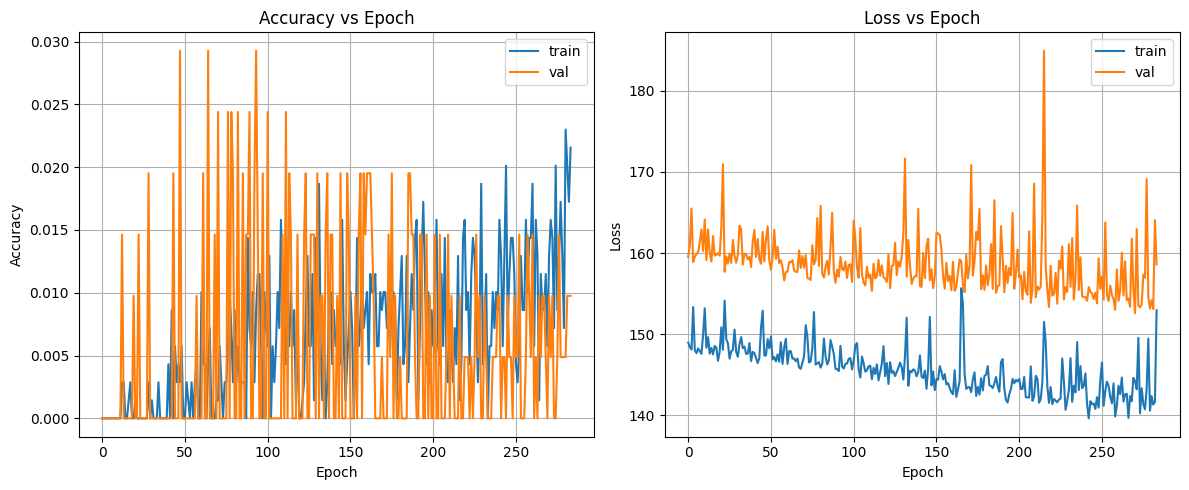

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (Accuracy vs Epoch)
axes[0].plot(train_acc[600:], label="train")
axes[0].plot(val_acc[600:], label="val")
axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs Epoch")
axes[0].grid()

# (Loss vs Epoch)
axes[1].plot(train_loss[600:], label="train")
axes[1].plot(val_loss[600:], label="val")
axes[1].legend()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss vs Epoch")
axes[1].grid()

plt.tight_layout()
plt.show()

In [60]:
# for i in range(360,390):
#     train_loss[i] = val_loss[i]

In [120]:
torch.save(model.state_dict(), "model_weights.pth")

In [121]:
# save the accuracy and loss
torch.save(train_acc, "train_acc.pth")
torch.save(val_acc, "val_acc.pth")
torch.save(train_loss, "train_loss.pth")
torch.save(val_loss, "val_loss.pth")

## Evaluation of the model on the test set

In [105]:
model.eval()

ParametricLPNet(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=25, bias=True)
    (3): ReLU()
    (4): Linear(in_features=25, out_features=48, bias=True)
    (5): ReLU()
    (6): Linear(in_features=48, out_features=26, bias=True)
  )
)

In [115]:
u = torch.tensor([[4.0]], dtype=torch.float64)
x = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u])
u,x

(tensor([[4.]], dtype=torch.float64),
 tensor([[59.9999, 19.9999]], dtype=torch.float64))

In [123]:
x_pred = model(torch.tensor([[4.0]]))
x_pred

tensor([[0., 0.]], grad_fn=<StackBackward0>)

In [119]:
x, x_pred, torch.norm(x - x_pred)

(tensor([[59.9999, 19.9999]], dtype=torch.float64),
 tensor([[0., 0.]], grad_fn=<StackBackward0>),
 tensor(63.2454, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>))

In [120]:
val_loop(test_dataloader, model, loss_fn)

Validation Error: 
 Accuracy: 29.3%, Avg loss: 1311.214806 




(1311.2148056030273, 0.2926829268292683)

# Part 3: Deep IO model

In [239]:
plp_learn = ExamplePLP([4.5])

In [260]:
u_show = io.tensor(np.linspace(0, 6, 10).reshape((-1, 1)))
x_show = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_show])

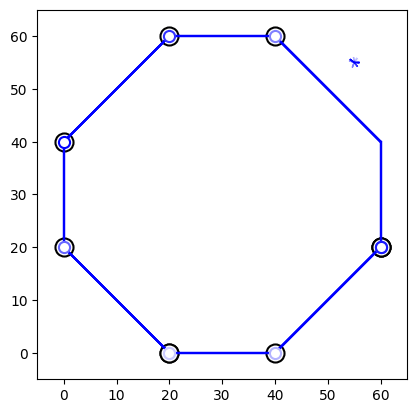

In [261]:
# Data set. Black points are the real solutions, blue points are the solutions of the plp_learn

iop.plot_targets(x_show, markersize=13)
iop.plot_parametric_linprog(plp_learn, u_show, color=[0, 0, 1], xylim=((-5,65),(-5,65)), cxy=(55,55), show_solutions=True)

In [258]:
io.inverse_parametric_linprog(u_train, x_train, plp_learn, max_steps=10,
                              callback=io.inverse_parametric_linprog_step_printer())

inverse_parametric_linprog[0001]: loss=208.002343 weights=[101.1330]
inverse_parametric_linprog[0002]: loss=194.813846 weights=[101.6415]
inverse_parametric_linprog[0003]: loss=100.553734 weights=[101.4860]
inverse_parametric_linprog[0004]: loss=43.037493 weights=[101.3028]
inverse_parametric_linprog[0005]: loss=25.247386 weights=[101.3701]
inverse_parametric_linprog[0006]: loss=4.585571 weights=[101.3358]
inverse_parametric_linprog[0007]: loss=1.146375 weights=[101.3337]
inverse_parametric_linprog[0008]: loss=1.117017 weights=[101.3301]
inverse_parametric_linprog[0009]: loss=0.000156 weights=[101.3314]
inverse_parametric_linprog[0010]: loss=0.000146 weights=[101.3313]
inverse_parametric_linprog[done]: loss=0.000120 weights=[101.3312]


(<__main__.ExamplePLP at 0x7d80c63b9910>,
 tensor(0.0001, dtype=torch.float64, grad_fn=<MeanBackward0>),
 tensor([[1.4457e-05, 2.0000e+01],
         [4.5017e-05, 4.0000e+01],
         [5.5164e-05, 4.0000e+01],
         ...,
         [6.0000e+01, 2.0000e+01],
         [2.0000e+01, 1.9671e-05],
         [1.9998e+01, 1.6924e-03]], dtype=torch.float64, grad_fn=<CatBackward0>))

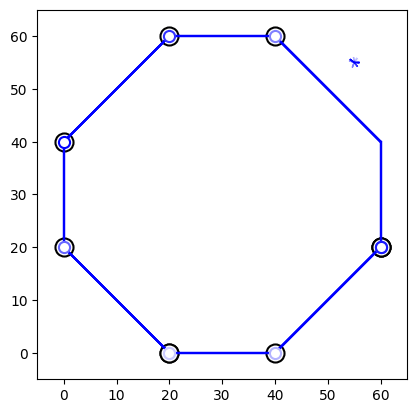

In [262]:
# Plot the new plp_learn, to show that the solutions (blue circles) now line up with the observed targets (black circles).
iop.plot_targets(x_show, markersize=13)
iop.plot_parametric_linprog(plp_learn, u_show, color=[0, 0, 1], xylim=((-5,65),(-5,65)), cxy=(55,55), show_solutions=True)

In [267]:
w = 101.3312

estimated_plp = ExamplePLP([w])

res = [torch.norm(x - io.linprog(*estimated_plp(u)).t())<0.1 for u, x in zip(u_test, x_test)]
print(f"Train accuracy: {100*sum(res)/len(res):.2f}%")

Train accuracy: 100.00%
